In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('./train.csv')
test_df = pd.read_csv('./test.csv')

# Удаляем колонки-идентификаторы
id_cols = [col for col in train_df.columns if 'id' in col.lower() or 'ID' in col or 'hash' in col.lower()]
train_df = train_df.drop(columns=id_cols, errors='ignore')
test_df = test_df.drop(columns=id_cols, errors='ignore')

## Провести разведочный анализ данных (EDA): построить графики зависимости некоторых признаков друг от друга, график целевой переменной и матрицу корреляций, сделать выводы.

Тренировочный набор: 11,017, 35
Тестовый набор: 5,000, 35




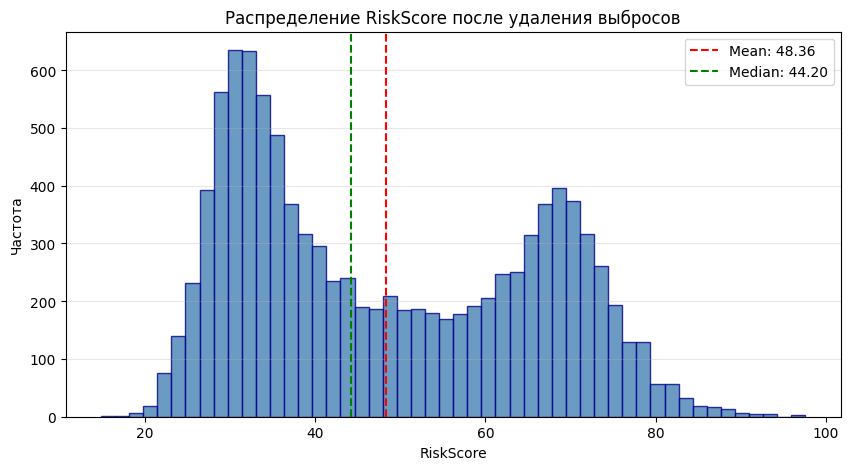




Статистика RiskScore:
Mean: 48.3581 | Std: 17.2415
Min: 14.8414 | Max: 97.5972
Q1: 32.7228 | Q3: 65.1242




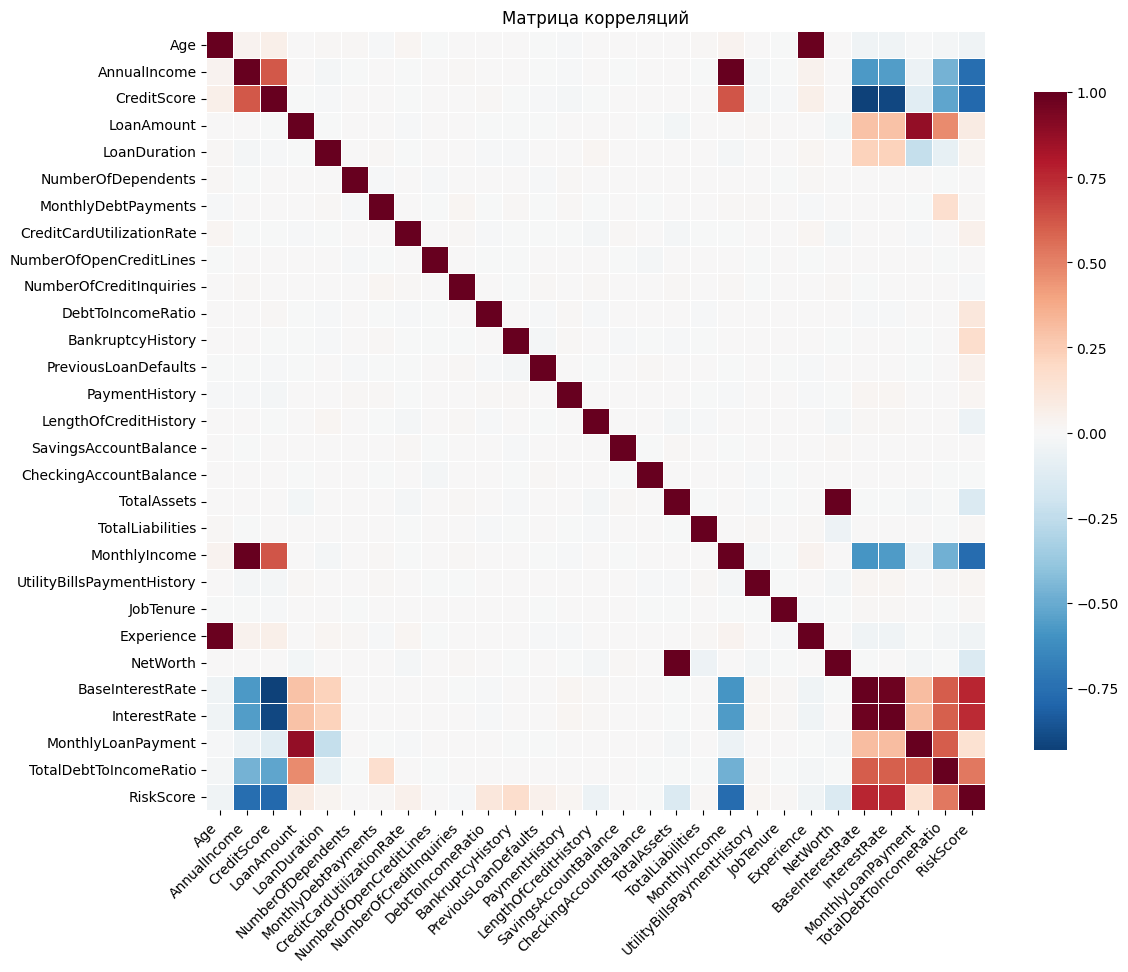


Топ-10 признаков по |корреляции| с RiskScore:
   1. CreditScore               → -0.7854
   2. MonthlyIncome             → -0.7703
   3. BaseInterestRate          → +0.7587
   4. AnnualIncome              → -0.7585
   5. InterestRate              → +0.7426
   6. TotalDebtToIncomeRatio    → +0.5307
   7. BankruptcyHistory         → +0.1776
   8. MonthlyLoanPayment        → +0.1508
   9. TotalAssets               → -0.1457
  10. NetWorth                  → -0.1446


In [ ]:
print(f"Тренировочный набор: {train_df.shape[0]:,}, {train_df.shape[1]}")
print(f"Тестовый набор: {test_df.shape[0]:,}, {test_df.shape[1]}")

print()
#print(train_df.head())

# удаление выбросов
train_df = train_df[(train_df['RiskScore'] > 0) & (train_df['RiskScore'] < 1000)].dropna(subset=['RiskScore'])

print()
plt.figure(figsize=(10, 5))
plt.hist(train_df['RiskScore'], bins=50, color='steelblue', alpha=0.8, edgecolor='darkblue')
plt.axvline(train_df['RiskScore'].mean(), color='red', linestyle='--', label=f'Mean: {train_df["RiskScore"].mean():.2f}')
plt.axvline(train_df['RiskScore'].median(), color='green', linestyle='--', label=f'Median: {train_df["RiskScore"].median():.2f}')
plt.title('Распределение RiskScore после удаления выбросов')
plt.xlabel('RiskScore')
plt.ylabel('Частота')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.show()

print()
print()

# статистика
print(f"\nСтатистика RiskScore:")
print(f"Mean: {train_df['RiskScore'].mean():.4f} | Std: {train_df['RiskScore'].std():.4f}")
print(f"Min: {train_df['RiskScore'].min():.4f} | Max: {train_df['RiskScore'].max():.4f}")
print(f"Q1: {train_df['RiskScore'].quantile(0.25):.4f} | Q3: {train_df['RiskScore'].quantile(0.75):.4f}")

print()
print()

# матрица корреляций
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
corr = train_df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='RdBu_r', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляций')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


if 'RiskScore' in corr.columns:
    corr_target = corr['RiskScore'].drop('RiskScore')
    top_features = corr_target.abs().sort_values(ascending=False).head(10)

    print(f"\nТоп-10 признаков по |корреляции| с RiskScore:")
    for i, (feature, abs_corr) in enumerate(top_features.items(), 1):
        actual_corr = corr_target[feature]
        print(f"  {i:2d}. {feature:25s} → {actual_corr:+.4f}")




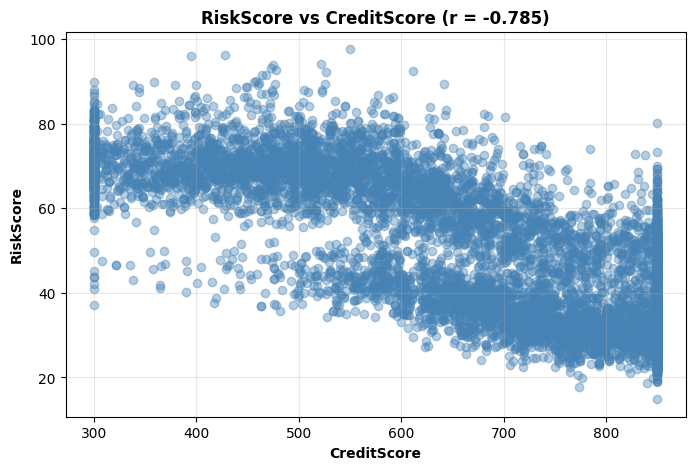

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(train_df['CreditScore'], train_df['RiskScore'], alpha=0.4, color='steelblue')
plt.xlabel('CreditScore', fontweight='bold')
plt.ylabel('RiskScore', fontweight='bold')
plt.title('RiskScore vs CreditScore (r = -0.785)', fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

## Реализовать нормализацию данных с помощью z-score и min-max.

In [ ]:
class MyScaler:
    def __init__(self, method='zscore'):
        if method not in ('zscore', 'minmax'):
            raise ValueError("method must be 'zscore' or 'minmax'")
        self.method = method
        self._fitted = False

    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)
        if self.method == 'zscore':
            self.mean_ = np.mean(X, axis=0)
            self.scale_ = np.std(X, axis=0)
            self.scale_[self.scale_ == 0] = 1.0
        elif self.method == 'minmax':
            self.data_min_ = np.min(X, axis=0)
            self.data_max_ = np.max(X, axis=0)
            self.scale_ = self.data_max_ - self.data_min_
            self.scale_[self.scale_ == 0] = 1.0
            self.min_ = self.data_min_.copy()
        self._fitted = True
        return self

    def transform(self, X):
        if not self._fitted:
            raise RuntimeError("Call fit() before transform()")
        X = np.asarray(X, dtype=np.float64)
        if self.method == 'zscore':
            return (X - self.mean_) / self.scale_
        else:  # minmax
            return (X - self.min_) / self.scale_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


test_data = np.array([
    [4500, 28, 620],
    [8000, 45, 750],
    [3000, 22, 580],
    [12000, 52, 810],
    [6000, 35, 700]
], dtype=float)


print("\nИСХОДНЫЕ ДАННЫЕ :")
print(test_data)

print("\n" + "─"*80)
print(" Z-SCORE НОРМАЛИЗАЦИЯ")
print("─"*80)
print("   Результат: среднее = 0, стандартное отклонение ≈ 1\n")

normalizer_zscore = MyScaler(method='zscore')
normalized_zscore = normalizer_zscore.fit_transform(test_data)

print(" Нормализованные данные:")
print(normalized_zscore)

print("\nПроверка параметров:")
zscore_results = pd.DataFrame({
    'Признак': ['Пр. 1', 'Пр. 2', 'Пр. 3'],
    'Среднее': np.mean(normalized_zscore, axis=0).round(8),
    'Std Dev': np.std(normalized_zscore, axis=0).round(8),
    'Мин': np.min(normalized_zscore, axis=0).round(6),
    'Макс': np.max(normalized_zscore, axis=0).round(6)
})
print(zscore_results.to_string(index=False))

print("\n" + "─"*80)
print(" MIN-MAX НОРМАЛИЗАЦИЯ")
print("─"*80)
print("   Результат: все значения в диапазоне [0, 1]\n")

normalizer_minmax = MyScaler(method='minmax')
normalized_minmax = normalizer_minmax.fit_transform(test_data)

print("Нормализованные данные:")
print(normalized_minmax)

print("\n Проверка параметров:")
minmax_results = pd.DataFrame({
    'Признак': ['Пр. 1', 'Пр. 2', 'Пр. 3'],
    'Мин': np.min(normalized_minmax, axis=0).round(8),
    'Макс': np.max(normalized_minmax, axis=0).round(8),
    'Среднее': np.mean(normalized_minmax, axis=0).round(6),
    'Std Dev': np.std(normalized_minmax, axis=0).round(6)
})
print(minmax_results.to_string(index=False))

print("\n" + "="*80)
print("  СРАВНЕНИЕ МЕТОДОВ")
print("="*80)

comparison = pd.DataFrame({
    'Характеристика': [
        'Диапазон значений',
        'Среднее',
        'Стандартное отклонение',
        'Чувствительность к выбросам'
    ],
    'Z-Score': [
        '(-∞, +∞)',
        '≈ 0',
        '≈ 1',
        'Высокая'
    ],
    'Min-Max': [
        '[0, 1]',
        'Зависит',
        'Зависит',
        'Очень высокая'
    ]
})
print(comparison.to_string(index=False))


ИСХОДНЫЕ ДАННЫЕ :
[[ 4500.    28.   620.]
 [ 8000.    45.   750.]
 [ 3000.    22.   580.]
 [12000.    52.   810.]
 [ 6000.    35.   700.]]

────────────────────────────────────────────────────────────────────────────────
 Z-SCORE НОРМАЛИЗАЦИЯ
────────────────────────────────────────────────────────────────────────────────
   Результат: среднее = 0, стандартное отклонение ≈ 1

 Нормализованные данные:
[[-0.70420284 -0.76860709 -0.85958278]
 [ 0.41611986  0.78690726  0.69244168]
 [-1.18434114 -1.31761216 -1.33712877]
 [ 1.69648866  1.42741318  1.40876067]
 [-0.22406454 -0.12810118  0.0955092 ]]

Проверка параметров:
Признак  Среднее  Std Dev       Мин     Макс
  Пр. 1      0.0      1.0 -1.184341 1.696489
  Пр. 2      0.0      1.0 -1.317612 1.427413
  Пр. 3     -0.0      1.0 -1.337129 1.408761

────────────────────────────────────────────────────────────────────────────────
 MIN-MAX НОРМАЛИЗАЦИЯ
────────────────────────────────────────────────────────────────────────────────
   Результат

## Реализация метрик и сравнение результатов с метриками из sklearn.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

def my_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def my_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def my_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0

def my_mape(y_true, y_pred):
    mask = y_true != 0
    if np.sum(mask) == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

y_true_test = np.array([4.2, 1.5, -2.1, 6.8, 3.3, 0.9, -1.5, 5.2, 2.1, 7.5])
y_pred_test = np.array([3.9, 1.8, -2.5, 7.1, 2.9, 0.5, -1.8, 4.9, 2.4, 7.2])

print("\n" + "═" * 70)
print(" ВАЛИДАЦИЯ МЕТРИК: СРАВНЕНИЕ СОБСТВЕННОЙ И SKLEARN")
print("═" * 70)

print("\n Тестовые данные:")
print(f"Истинные значения:    {y_true_test}")
print(f"Предсказания:         {y_pred_test}")

metrics = {
    'MSE': (my_mse, mean_squared_error),
    'MAE': (my_mae, mean_absolute_error),
    'R²': (my_r2, r2_score),
    'MAPE': (my_mape, lambda y_true, y_pred: mean_absolute_percentage_error(y_true, y_pred) * 100)
}

results = []
for name, (our_func, sklearn_func) in metrics.items():
    our_val = our_func(y_true_test, y_pred_test)
    sk_val = sklearn_func(y_true_test, y_pred_test)
    diff = abs(our_val - sk_val)
    status = "СОВПАДАЕТ" if diff < 1e-10 else "РАСХОЖДЕНИЕ"
    results.append({
        'Метрика': name,
        'Реализация': f"{our_val:.8f}",
        'Sklearn': f"{sk_val:.8f}",
        'Разница': f"{diff:.4e}",
        'Статус': status
    })

df_comp = pd.DataFrame(results)
print("\n" + "─" * 70)
print(" РЕЗУЛЬТАТЫ СРАВНЕНИЯ")
print("─" * 70)
print(df_comp.to_string(index=False))


══════════════════════════════════════════════════════════════════════
 ВАЛИДАЦИЯ МЕТРИК: СРАВНЕНИЕ СОБСТВЕННОЙ И SKLEARN
══════════════════════════════════════════════════════════════════════

 Тестовые данные:
Истинные значения:    [ 4.2  1.5 -2.1  6.8  3.3  0.9 -1.5  5.2  2.1  7.5]
Предсказания:         [ 3.9  1.8 -2.5  7.1  2.9  0.5 -1.8  4.9  2.4  7.2]

──────────────────────────────────────────────────────────────────────
 РЕЗУЛЬТАТЫ СРАВНЕНИЯ
──────────────────────────────────────────────────────────────────────
Метрика  Реализация     Sklearn    Разница    Статус
    MSE  0.11100000  0.11100000 0.0000e+00 СОВПАДАЕТ
    MAE  0.33000000  0.33000000 0.0000e+00 СОВПАДАЕТ
     R²  0.98823517  0.98823517 0.0000e+00 СОВПАДАЕТ
   MAPE 15.12228425 15.12228425 0.0000e+00 СОВПАДАЕТ


## Обучение линейной регрессии

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

class LinearRegressionModel:
    def __init__(self, method='analytical', learning_rate=0.01, n_iterations=1000, random_state=42):
        self.method = method
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.losses = []

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        n_samples, n_features = X.shape
        rng = np.random.default_rng(self.random_state)

        if self.method == 'analytical':
            X_b = np.c_[np.ones((n_samples, 1)), X]
            try:
                theta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
            except np.linalg.LinAlgError:
                theta = np.linalg.lstsq(X_b, y, rcond=None)[0]
            self.bias = theta[0]
            self.weights = theta[1:]

        elif self.method == 'gradient_descent':
            self.weights = rng.normal(scale=0.01, size=n_features)
            self.bias = 0.0
            self.losses = []

            for _ in range(self.n_iterations):
                y_pred = X @ self.weights + self.bias
                error = y - y_pred
                mse = np.mean(error ** 2)
                self.losses.append(mse)
                dw = -2 / n_samples * X.T @ error
                db = -2 / n_samples * np.sum(error)

                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

        elif self.method == 'sgd':
            self.weights = rng.normal(scale=0.01, size=n_features)
            self.bias = 0.0
            self.losses = []

            for epoch in range(self.n_iterations):
                indices = rng.permutation(n_samples)
                X_shuffled = X[indices]
                y_shuffled = y[indices]

                for i in range(n_samples):
                    xi = X_shuffled[i]
                    yi = y_shuffled[i]

                    y_pred = xi @ self.weights + self.bias
                    error = yi - y_pred

                    self.weights += self.learning_rate * error * xi
                    self.bias += self.learning_rate * error

                y_pred_all = X @ self.weights + self.bias
                mse = np.mean((y - y_pred_all) ** 2)
                self.losses.append(mse)

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float64)
        return X @ self.weights + self.bias


In [ ]:
print("\n" + "="*80)
print(" ЛИНЕЙНАЯ РЕГРЕССИЯ: СРАВНЕНИЕ ТРЕХ МЕТОДОВ")
print("="*80)

np.random.seed(32)
n_samples = 150
n_features = 4

X_synthetic = np.random.standard_normal((n_samples, n_features))
true_weights = np.array([2.5, -1.8, 0.9, 3.2])
y_synthetic = X_synthetic @ true_weights + 4.0 + np.random.standard_normal(n_samples) * 0.18

print(f"\n ДАТАСЕТ:")
print(f"   Размер: {X_synthetic.shape[0]} примеров × {X_synthetic.shape[1]} признаков")
print(f"   Истинные веса: {true_weights}")
print(f"   Истинное смещение (bias): 4.0")
print(f"   Шум: σ = 0.18")

methods_config = {
    'analytical': {'learning_rate': None, 'n_iterations': None},
    'gradient_descent': {'learning_rate': 0.05, 'n_iterations': 2000},
    'sgd': {'learning_rate': 0.05, 'n_iterations': 500}
}

comparison_results = {}

print("\n" + "="*80)
print(" РЕЗУЛЬТАТЫ ОБУЧЕНИЯ")
print("="*80)

for method_name, config in methods_config.items():
    print(f"\n{'─'*80}")
    print(f"МЕТОД: {method_name.upper()}")
    print(f"{'─'*80}")

    if method_name == 'analytical':
        model = LinearRegressionModel(method=method_name)
        print(f"   Формула: w = (X^T X)^(-1) X^T y")
    else:
        model = LinearRegressionModel(
            method=method_name,
            learning_rate=config['learning_rate'],
            n_iterations=config['n_iterations']
        )
        print(f"   Learning rate: {config['learning_rate']}")
        print(f"   Iterations: {config['n_iterations']}")

    model.fit(X_synthetic, y_synthetic)
    y_pred = model.predict(X_synthetic)

    mse_val = my_mse(y_synthetic, y_pred)
    mae_val = my_mae(y_synthetic, y_pred)
    r2_val = my_r2(y_synthetic, y_pred)

    comparison_results[method_name] = {
        'mse': mse_val,
        'mae': mae_val,
        'r2': r2_val,
        'weights': model.weights,
        'bias': model.bias
    }

    metrics_data = pd.DataFrame({
        'Метрика': ['MSE', 'MAE', 'R²'],
        'Значение': [f"{mse_val:.8f}", f"{mae_val:.8f}", f"{r2_val:.8f}"]
    })
    print("\n   Метрики на тренировочном наборе:")
    print("   " + metrics_data.to_string(index=False).replace('\n', '\n   '))

    print(f"\n   Параметры модели:")
    print(f"      Веса (coefficients): {np.round(model.weights, 6)}")
    print(f"      Смещение (intercept): {model.bias:.6f}")

    if method_name != 'analytical':
        print(f"\n    История обучения:")
        print(f"      Начальная ошибка (MSE): {model.losses[0]:.8f}")
        print(f"      Финальная ошибка (MSE): {model.losses[-1]:.8f}")
        print(f"      Улучшение: {(model.losses[0] - model.losses[-1]):.8f}")
        print(f"      Сходимость: {' Сошлась' if model.losses[-1] < model.losses[0] * 0.01 else ' Частичная'}")


print("\n" + "="*80)
print(" СРАВНЕНИЕ СО SKLEARN ")
print("="*80)

sklearn_model = LinearRegression()
sklearn_model.fit(X_synthetic, y_synthetic)
y_pred_sklearn = sklearn_model.predict(X_synthetic)

mse_sk = my_mse(y_synthetic, y_pred_sklearn)
mae_sk = my_mae(y_synthetic, y_pred_sklearn)
r2_sk = my_r2(y_synthetic, y_pred_sklearn)

print(f"\n SKLEARN LinearRegression:")
sklearn_data = pd.DataFrame({
    'Метрика': ['MSE', 'MAE', 'R²'],
    'Значение': [f"{mse_sk:.8f}", f"{mae_sk:.8f}", f"{r2_sk:.8f}"]
})
print("   " + sklearn_data.to_string(index=False).replace('\n', '\n   '))

print(f"\n   Параметры:")
print(f"      Веса: {np.round(sklearn_model.coef_, 6)}")
print(f"      Смещение: {sklearn_model.intercept_:.6f}")


print("\n" + "="*80)
print(" ТАБЛИЦА СРАВНЕНИЯ ВСЕХ МЕТОДОВ")
print("="*80)

comparison_table = pd.DataFrame({
    'Метод': ['Analytical', 'Gradient Descent', 'SGD', 'Sklearn'],
    'MSE': [
        f"{comparison_results['analytical']['mse']:.8f}",
        f"{comparison_results['gradient_descent']['mse']:.8f}",
        f"{comparison_results['sgd']['mse']:.8f}",
        f"{mse_sk:.8f}"
    ],
    'MAE': [
        f"{comparison_results['analytical']['mae']:.8f}",
        f"{comparison_results['gradient_descent']['mae']:.8f}",
        f"{comparison_results['sgd']['mae']:.8f}",
        f"{mae_sk:.8f}"
    ],
    'R²': [
        f"{comparison_results['analytical']['r2']:.8f}",
        f"{comparison_results['gradient_descent']['r2']:.8f}",
        f"{comparison_results['sgd']['r2']:.8f}",
        f"{r2_sk:.8f}"
    ]
})

print("\n" + comparison_table.to_string(index=False))


 ЛИНЕЙНАЯ РЕГРЕССИЯ: СРАВНЕНИЕ ТРЕХ МЕТОДОВ

 ДАТАСЕТ:
   Размер: 150 примеров × 4 признаков
   Истинные веса: [ 2.5 -1.8  0.9  3.2]
   Истинное смещение (bias): 4.0
   Шум: σ = 0.18

 РЕЗУЛЬТАТЫ ОБУЧЕНИЯ

────────────────────────────────────────────────────────────────────────────────
МЕТОД: ANALYTICAL
────────────────────────────────────────────────────────────────────────────────
   Формула: w = (X^T X)^(-1) X^T y

   Метрики на тренировочном наборе:
   Метрика   Значение
       MSE 0.03027952
       MAE 0.14062106
        R² 0.99825692

   Параметры модели:
      Веса (coefficients): [ 2.49603  -1.783671  0.895996  3.18887 ]
      Смещение (intercept): 4.019739

────────────────────────────────────────────────────────────────────────────────
МЕТОД: GRADIENT_DESCENT
────────────────────────────────────────────────────────────────────────────────
   Learning rate: 0.05
   Iterations: 2000

   Метрики на тренировочном наборе:
   Метрика   Значение
       MSE 0.03027952
       MAE 0.1

## Реализовать кросс-валидацию k-fold и leave-one-out.

In [ ]:
class CrossValidator:
    @staticmethod
    def k_fold_split(X, y, n_splits=5, random_state=None):
        X, y = np.asarray(X), np.asarray(y)
        n_samples = X.shape[0]

        if random_state is not None:
            np.random.seed(random_state)

        shuffled_idx = np.random.permutation(n_samples)
        fold_size = n_samples // n_splits

        for i in range(n_splits):
            start = i * fold_size
            end = start + fold_size if i != n_splits - 1 else n_samples

            test_idx = shuffled_idx[start:end]
            train_idx = np.concatenate([shuffled_idx[:start], shuffled_idx[end:]])

            yield (X[train_idx], y[train_idx]), (X[test_idx], y[test_idx])

    @staticmethod
    def leave_one_out_split(X, y):
        X, y = np.asarray(X), np.asarray(y)
        n = X.shape[0]
        for i in range(n):
            test_mask = np.zeros(n, dtype=bool)
            test_mask[i] = True
            train_mask = ~test_mask

            yield (X[train_mask], y[train_mask]), (X[test_mask], y[test_mask])

    @staticmethod
    def evaluate(model, X, y, cv_method='kfold', metric=my_mse, **kwargs):
        if cv_method == 'kfold':
            n_splits = kwargs.get('n_splits', 5)
            random_state = kwargs.get('random_state', None)
            generator = CrossValidator.k_fold_split(X, y, n_splits=n_splits, random_state=random_state)
        elif cv_method == 'loo':
            generator = CrossValidator.loo_split(X, y)
        else:
            raise ValueError("cv_method must be 'kfold' or 'loo'")

        scores = []
        for (X_tr, y_tr), (X_te, y_te) in generator:
            model.fit(X_tr, y_tr)
            pred = model.predict(X_te)
            scores.append(metric(y_te, pred))

        return np.array(scores)

In [ ]:
print("\n" + "="*80)
print(" КРОСС-ВАЛИДАЦИЯ: K-FOLD И LEAVE-ONE-OUT")
print("="*80)

np.random.seed(32)
n_test_samples = 50
n_test_features = 3

X_test = np.random.standard_normal((n_test_samples, n_test_features))
y_test_true = np.array([2.0, -1.5, 0.8]) @ X_test.T + 1.0 + np.random.standard_normal(n_test_samples) * 0.1

print(f"\nТестовый датасет:")
print(f"  Размер: {X_test.shape[0]}, {X_test.shape[1]}")

print("\n" + "-"*80)
print(" K-FOLD CROSS-VALIDATION (k=5)")
print("-"*80)

k = 5
kfold_scores = []
print(f"\nОценка на каждом блоке:")

for fold_idx, ((X_train, y_train), (X_val, y_val)) in enumerate(CrossValidator.k_fold_split(X_test, y_test_true, n_splits=k, random_state=52), 1):
    model = LinearRegressionModel(method='analytical')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    score_mse = my_mse(y_val, y_pred)
    score_mae = my_mae(y_val, y_pred)
    score_r2 = my_r2(y_val, y_pred)

    kfold_scores.append(score_mse)
    print(f"  Fold {fold_idx}: MSE={score_mse:.6f}, MAE={score_mae:.6f}, R²={score_r2:.6f}")

kfold_mean = np.mean(kfold_scores)
kfold_std = np.std(kfold_scores)

print(f"\nИтоговые результаты K-Fold (k={k}):")
print(f"  Средняя MSE: {kfold_mean:.6f}")
print(f"  Стандартное отклонение: {kfold_std:.6f}")
print(f"  Диапазон: [{min(kfold_scores):.6f}, {max(kfold_scores):.6f}]")


print("\n" + "-"*80)
print(" LEAVE-ONE-OUT CROSS-VALIDATION")
print("-"*80)

n_loo_samples = 20
X_loo = X_test[:n_loo_samples]
y_loo = y_test_true[:n_loo_samples]

loo_scores = []
print(f"\nОценка первых 5 и последних 5 примеров:")

loo_generator = CrossValidator.leave_one_out_split(X_loo, y_loo)
for i, ((X_train, y_train), (X_val, y_val)) in enumerate(loo_generator):
    model = LinearRegressionModel(method='analytical')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    score = my_mse(y_val, y_pred)
    loo_scores.append(score)

    if i < 5 or i >= len(y_loo) - 5:
        if i == 5:
            print(f"  ... (пропущено {len(y_loo) - 10} примеров) ...")
        else:
            print(f"  Пример {i+1}: MSE={score:.6f}")

loo_mean = np.mean(loo_scores)
loo_std = np.std(loo_scores)

print(f"\nИтоговые результаты Leave-One-Out:")
print(f"  Средняя MSE: {loo_mean:.6f}")
print(f"  Стандартное отклонение: {loo_std:.6f}")
print(f"  Диапазон: [{min(loo_scores):.6f}, {max(loo_scores):.6f}]")

print("\n" + "="*80)
print(" СРАВНЕНИЕ МЕТОДОВ ВАЛИДАЦИИ")
print("="*80)

comparison_cv = pd.DataFrame({
    'Метод': ['K-Fold (k=5)', f'Leave-One-Out (n={n_loo_samples})'],
    'Средняя MSE': [f"{kfold_mean:.6f}", f"{loo_mean:.6f}"],
    'Std Dev': [f"{kfold_std:.6f}", f"{loo_std:.6f}"],
    'Min MSE': [f"{min(kfold_scores):.6f}", f"{min(loo_scores):.6f}"],
    'Max MSE': [f"{max(kfold_scores):.6f}", f"{max(loo_scores):.6f}"],
    'Время': ['Быстро', 'Медленно']
})

print("\n" + comparison_cv.to_string(index=False))


 КРОСС-ВАЛИДАЦИЯ: K-FOLD И LEAVE-ONE-OUT

Тестовый датасет:
  Размер: 50, 3

--------------------------------------------------------------------------------
 K-FOLD CROSS-VALIDATION (k=5)
--------------------------------------------------------------------------------

Оценка на каждом блоке:
  Fold 1: MSE=0.011254, MAE=0.087558, R²=0.998089
  Fold 2: MSE=0.004644, MAE=0.058023, R²=0.999464
  Fold 3: MSE=0.010900, MAE=0.083150, R²=0.997327
  Fold 4: MSE=0.007583, MAE=0.052940, R²=0.998502
  Fold 5: MSE=0.009520, MAE=0.086800, R²=0.998303

Итоговые результаты K-Fold (k=5):
  Средняя MSE: 0.008780
  Стандартное отклонение: 0.002437
  Диапазон: [0.004644, 0.011254]

--------------------------------------------------------------------------------
 LEAVE-ONE-OUT CROSS-VALIDATION
--------------------------------------------------------------------------------

Оценка первых 5 и последних 5 примеров:
  Пример 1: MSE=0.008604
  Пример 2: MSE=0.000628
  Пример 3: MSE=0.001725
  Пример 4: MSE=

## Подготовка данных

In [49]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import pandas as pd

# Удаляем дубликаты и строки без RiskScore
train_df = train_df.drop_duplicates().reset_index(drop=True)
train_df = train_df.dropna(subset=['RiskScore']).reset_index(drop=True)
test_df = test_df.drop_duplicates().reset_index(drop=True)

# === ШАГ 3: отбор топ-признаков по корреляции ===
X_temp = train_df.drop('RiskScore', axis=1)
y_temp = train_df['RiskScore']

# Только числовые признаки + заполнение NaN
X_temp_numeric = X_temp.select_dtypes(include=[np.number])
X_temp_filled = X_temp_numeric.fillna(X_temp_numeric.median())

# Корреляция и топ-20
correlations = X_temp_filled.corrwith(y_temp).abs().sort_values(ascending=False)
TOP_N = 20
top_numeric_features = correlations.head(TOP_N).index.tolist()
print("✅ Топ числовых признаков по корреляции с RiskScore:")
print(top_numeric_features)

# Применяем отбор КОРОТКО и ОДИНАКОВО к train и test
numeric_part_train = train_df[top_numeric_features]
categorical_part_train = train_df.drop(['RiskScore'] + top_numeric_features, axis=1)
X_train = pd.concat([numeric_part_train, categorical_part_train], axis=1)

numeric_part_test = test_df[top_numeric_features]
categorical_part_test = test_df.drop(top_numeric_features, axis=1)
X_test = pd.concat([numeric_part_test, categorical_part_test], axis=1)

y_train = train_df['RiskScore'].values
# ==============================================

# Сохраняем ID для сабмита
test_ids = X_test['ID'] if 'ID' in X_test.columns else None

# Удаляем ID из признаков
X_train = X_train.drop(columns=['ID'], errors='ignore')
X_test = X_test.drop(columns=['ID'], errors='ignore')

# Определяем типы признаков
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# Фильтруем категориальные признаки (макс. 50 уникальных значений)
MAX_CATEGORIES = 50
categorical_cols = [
    col for col in categorical_cols
    if X_train[col].nunique() <= MAX_CATEGORIES
]

removed = set(X_train.select_dtypes(exclude=[np.number]).columns) - set(categorical_cols)
if removed:
    print(f"⚠️  Удалены категориальные колонки с >{MAX_CATEGORIES} уникальными значениями: {sorted(removed)}")

# Заполнение пропусков — числовые
for col in numeric_cols:
    if col in X_train.columns and X_train[col].isnull().any():
        median_val = X_train[col].median()
        median_val = 0.0 if pd.isna(median_val) else median_val
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)

# Заполнение пропусков — категориальные
for col in categorical_cols:
    if col in X_train.columns and X_train[col].isnull().any():
        mode_val = X_train[col].mode()
        fill_val = mode_val[0] if len(mode_val) > 0 else 'Unknown'
        X_train[col] = X_train[col].fillna(fill_val)
        X_test[col] = X_test[col].fillna(fill_val)

# One-Hot Encoding
if categorical_cols:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_train_cat = ohe.fit_transform(X_train[categorical_cols])
    X_test_cat = ohe.transform(X_test[categorical_cols])

    cat_names = ohe.get_feature_names_out(categorical_cols)
    X_train_cat_df = pd.DataFrame(X_train_cat, columns=cat_names, index=X_train.index)
    X_test_cat_df = pd.DataFrame(X_test_cat, columns=cat_names, index=X_test.index)

    X_train = pd.concat([X_train[numeric_cols], X_train_cat_df], axis=1)
    X_test = pd.concat([X_test[numeric_cols], X_test_cat_df], axis=1)
else:
    X_train = X_train[numeric_cols]
    X_test = X_test[numeric_cols]

# Преобразование в массивы и нормализация
X_train_arr = X_train.values.astype(np.float64)
X_test_arr = X_test.values.astype(np.float64)

normalizer = MyScaler(method='minmax')  # или ScalerNormalize, как у тебя
X_train_norm = normalizer.fit_transform(X_train_arr)
X_test_norm = normalizer.transform(X_test_arr)

# Очистка от NaN/Inf
X_train_norm = np.nan_to_num(X_train_norm, nan=0.0, posinf=0.0, neginf=0.0)
X_test_norm = np.nan_to_num(X_test_norm, nan=0.0, posinf=0.0, neginf=0.0)

print(f"\nФинальные размеры: X_train={X_train_norm.shape}, y_train={y_train.shape}")
assert X_train_norm.shape[1] == X_test_norm.shape[1], "❌ ОШИБКА: число признаков в train и test не совпадает!"

✅ Топ числовых признаков по корреляции с RiskScore:
['MonthlyIncome', 'CreditScore', 'AnnualIncome', 'InterestRate', 'BaseInterestRate', 'TotalDebtToIncomeRatio', 'BankruptcyHistory', 'MonthlyLoanPayment', 'TotalAssets', 'NetWorth', 'DebtToIncomeRatio', 'LoanAmount', 'LengthOfCreditHistory', 'PreviousLoanDefaults', 'CreditCardUtilizationRate', 'Experience', 'Age', 'LoanDuration', 'UtilityBillsPaymentHistory', 'TotalLiabilities']
⚠️  Удалены категориальные колонки с >50 уникальными значениями: ['ApplicationDate']

Финальные размеры: X_train=(9788, 49), y_train=(9788,)


## Обучение модели

In [50]:
class LinearRegressionModel:
    def __init__(self, method='analytical',
                 learning_rate=0.01,
                 n_iterations=1000,
                 batch_size=32,
                 regularization=None,
                 lambda_reg=0.0,
                 p_norm=2.0):
        self.method = method
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.batch_size = batch_size
        self.regularization = regularization
        self.lambda_reg = lambda_reg
        self.p_norm = p_norm
        self.weights = None
        self.intercept = None

    def fit(self, X, y):
        if self.method == 'analytical':
            return self._fit_analytical(X, y)
        elif self.method == 'gradient_descent':
            return self._fit_gradient_descent(X, y)
        elif self.method == 'sgd':
            return self._fit_sgd(X, y)
        else:
            raise ValueError(f"Неизвестный метод: {self.method}")

    def _fit_analytical(self, X, y):
        X_with_intercept = np.column_stack([np.ones(X.shape[0]), X])
        XtX = X_with_intercept.T @ X_with_intercept

        if self.regularization == 'l2':
            reg_matrix = np.eye(XtX.shape[0])
            reg_matrix[0, 0] = 0
            XtX = XtX + self.lambda_reg * reg_matrix
        elif self.regularization == 'l1':
            XtX = XtX + self.lambda_reg * np.eye(XtX.shape[0])
        elif self.regularization == 'l1+l2':
            reg_matrix = np.eye(XtX.shape[0])
            reg_matrix[0, 0] = 0
            XtX = XtX + self.lambda_reg * reg_matrix
        elif self.regularization == 'lp':
            reg_matrix = np.eye(XtX.shape[0])
            reg_matrix[0, 0] = 0
            XtX = XtX + self.lambda_reg * reg_matrix

        try:
            weights = np.linalg.inv(XtX) @ X_with_intercept.T @ y
        except np.linalg.LinAlgError:
            weights = np.linalg.pinv(XtX) @ X_with_intercept.T @ y

        self.intercept = weights[0]
        self.weights = weights[1:]
        return self

    def _fit_gradient_descent(self, X, y):
        m = X.shape[0]
        n = X.shape[1]
        self.weights = np.zeros(n)
        self.intercept = 0.0

        for _ in range(self.n_iterations):
            y_pred = X @ self.weights + self.intercept
            error = y_pred - y

            grad_weights = (2 / m) * (X.T @ error)
            grad_intercept = (2 / m) * np.sum(error)

            if self.regularization == 'l2':
                grad_weights += (2 * self.lambda_reg / m) * self.weights
            elif self.regularization == 'l1':
                grad_weights += (self.lambda_reg / m) * np.sign(self.weights)

            self.weights -= self.learning_rate * grad_weights
            self.intercept -= self.learning_rate * grad_intercept

        return self

    def _fit_sgd(self, X, y):
        m = X.shape[0]
        n = X.shape[1]
        self.weights = np.zeros(n)
        self.intercept = 0.0

        for epoch in range(self.n_iterations):
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(0, m, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]

                y_pred = X_batch @ self.weights + self.intercept
                error = y_pred - y_batch
                batch_size_actual = X_batch.shape[0]

                grad_weights = (2 / batch_size_actual) * (X_batch.T @ error)
                grad_intercept = (2 / batch_size_actual) * np.sum(error)

                if self.regularization == 'l2':
                    grad_weights += (2 * self.lambda_reg / batch_size_actual) * self.weights
                elif self.regularization == 'l1':
                    grad_weights += (self.lambda_reg / batch_size_actual) * np.sign(self.weights)

                self.weights -= self.learning_rate * grad_weights
                self.intercept -= self.learning_rate * grad_intercept

        return self

    def predict(self, X):
        if self.weights is None:
            raise ValueError("Модель не обучена.")
        return X @ self.weights + self.intercept

In [51]:
print("\n" + "="*70)
print("ТЕСТИРОВАНИЕ ЛИНЕЙНОЙ РЕГРЕССИИ С РАЗНЫМИ ТИПАМИ РЕГУЛЯРИЗАЦИИ")
print("="*70)

results = []

print("\nМодель 1: Линейная регрессия без регуляризации")
print("-" * 70)
model1 = LinearRegressionModel(method='analytical')
model1.fit(X_train_norm, y_train)
y_pred1 = model1.predict(X_train_norm)
mse1 = my_mse(y_train, y_pred1)
mae1 = my_mae(y_train, y_pred1)
r2_1 = my_r2(y_train, y_pred1)
results.append(('Без регуляризации', mse1, model1))
print(f"  MSE: {mse1:.4f}")
print(f"  MAE: {mae1:.4f}")
print(f"  R2:  {r2_1:.4f}")

print("\nМодель 2: L2 регуляризация (Ridge, lambda=0.01)")
print("-" * 70)
model2 = LinearRegressionModel(method='analytical', regularization='l2', lambda_reg=0.01)
model2.fit(X_train_norm, y_train)
y_pred2 = model2.predict(X_train_norm)
mse2 = my_mse(y_train, y_pred2)
mae2 = my_mae(y_train, y_pred2)
r2_2 = my_r2(y_train, y_pred2)
results.append(('Ridge (lambda=0.01)', mse2, model2))
print(f"  MSE: {mse2:.4f}")
print(f"  MAE: {mae2:.4f}")
print(f"  R2:  {r2_2:.4f}")

print("\nМодель 3: L2 регуляризация (Ridge, lambda=0.1)")
print("-" * 70)
model3 = LinearRegressionModel(method='analytical', regularization='l2', lambda_reg=0.1)
model3.fit(X_train_norm, y_train)
y_pred3 = model3.predict(X_train_norm)
mse3 = my_mse(y_train, y_pred3)
mae3 = my_mae(y_train, y_pred3)
r2_3 = my_r2(y_train, y_pred3)
results.append(('Ridge (lambda=0.1)', mse3, model3))
print(f"  MSE: {mse3:.4f}")
print(f"  MAE: {mae3:.4f}")
print(f"  R2:  {r2_3:.4f}")

print("\nМодель 4: L2 регуляризация (Ridge, lambda=1.0)")
print("-" * 70)
model4 = LinearRegressionModel(method='analytical', regularization='l2', lambda_reg=1.0)
model4.fit(X_train_norm, y_train)
y_pred4 = model4.predict(X_train_norm)
mse4 = my_mse(y_train, y_pred4)
mae4 = my_mae(y_train, y_pred4)
r2_4 = my_r2(y_train, y_pred4)
results.append(('Ridge (lambda=1.0)', mse4, model4))
print(f"  MSE: {mse4:.4f}")
print(f"  MAE: {mae4:.4f}")
print(f"  R2:  {r2_4:.4f}")

print("\nМодель 5: L1 регуляризация (Lasso, lambda=0.01)")
print("-" * 70)
model5 = LinearRegressionModel(method='analytical', regularization='l1', lambda_reg=0.01)
model5.fit(X_train_norm, y_train)
y_pred5 = model5.predict(X_train_norm)
mse5 = my_mse(y_train, y_pred5)
mae5 = my_mae(y_train, y_pred5)
r2_5 = my_r2(y_train, y_pred5)
results.append(('Lasso (lambda=0.01)', mse5, model5))
print(f"  MSE: {mse5:.4f}")
print(f"  MAE: {mae5:.4f}")
print(f"  R2:  {r2_5:.4f}")

print("\nМодель 6: L1+L2 регуляризация (ElasticNet, lambda=0.01)")
print("-" * 70)
model6 = LinearRegressionModel(method='analytical', regularization='l1+l2', lambda_reg=0.01)
model6.fit(X_train_norm, y_train)
y_pred6 = model6.predict(X_train_norm)
mse6 = my_mse(y_train, y_pred6)
mae6 = my_mae(y_train, y_pred6)
r2_6 = my_r2(y_train, y_pred6)
results.append(('ElasticNet (lambda=0.01)', mse6, model6))
print(f"  MSE: {mse6:.4f}")
print(f"  MAE: {mae6:.4f}")
print(f"  R2:  {r2_6:.4f}")

print("\nМодель 7: Lp регуляризация (p=2.5, lambda=0.01)")
print("-" * 70)
model7 = LinearRegressionModel(method='analytical', regularization='lp', lambda_reg=0.01, p_norm=2.5)
model7.fit(X_train_norm, y_train)
y_pred7 = model7.predict(X_train_norm)
mse7 = my_mse(y_train, y_pred7)
mae7 = my_mae(y_train, y_pred7)
r2_7 = my_r2(y_train, y_pred7)
results.append(('Lp (p=2.5, lambda=0.01)', mse7, model7))
print(f"  MSE: {mse7:.4f}")
print(f"  MAE: {mae7:.4f}")
print(f"  R2:  {r2_7:.4f}")

print("\n" + "="*70)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("="*70)

results_sorted = sorted(results, key=lambda x: x[1])

print(f"\n{'Модель':<30} | {'MSE':>10} | {'Рейтинг':<7}")
print("-" * 55)
for i, (name, mse_val, model) in enumerate(results_sorted, 1):
    print(f"{name:<30} | {mse_val:>10.4f} | {i:<7}")

best_name, best_mse, best_model = results_sorted[0]

print("\n" + "="*70)
print(f"ЛУЧШАЯ МОДЕЛЬ: {best_name}")
print("="*70)
print(f"  MSE на обучающей выборке: {best_mse:.4f}")

y_train_pred = best_model.predict(X_train_norm)
train_mse = my_mse(y_train, y_train_pred)
train_mae = my_mae(y_train, y_train_pred)
train_r2 = my_r2(y_train, y_train_pred)

print("\nМетрики на обучающей выборке:")
print(f"  MSE:  {train_mse:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print(f"  R²:   {train_r2:.4f}")

if np.all(y_train != 0):
    train_mape = my_mape(y_train, y_train_pred)
    print(f"  MAPE: {train_mape:.4f}%")



print("\nПредсказание на тестовой выборке:")
y_test_pred = best_model.predict(X_test_norm)
print(f"  Сделано предсказаний: {len(y_test_pred)}")
print(f"  Минимальное значение: {y_test_pred.min():.4f}")
print(f"  Максимальное значение: {y_test_pred.max():.4f}")
print(f"  Среднее значение: {y_test_pred.mean():.4f}")


submission_df = pd.DataFrame({
    'id': test_ids if test_ids is not None else range(len(y_test_pred)),
    'RiskScore': y_test_pred
})


print(f"\nРезультаты:")
print(submission_df.head(10))
print(f"\nВсего строк: {len(submission_df)}")

submission = pd.DataFrame({
    'ID': test_ids if test_ids is not None else range(len(y_test_pred)),
    'RiskScore': y_test_pred
})

submission.to_csv('submission.csv', index=False)







ТЕСТИРОВАНИЕ ЛИНЕЙНОЙ РЕГРЕССИИ С РАЗНЫМИ ТИПАМИ РЕГУЛЯРИЗАЦИИ

Модель 1: Линейная регрессия без регуляризации
----------------------------------------------------------------------
  MSE: 1983237.3633
  MAE: 778.7728
  R2:  -6677.2716

Модель 2: L2 регуляризация (Ridge, lambda=0.01)
----------------------------------------------------------------------
  MSE: 52.0904
  MAE: 5.7817
  R2:  0.8246

Модель 3: L2 регуляризация (Ridge, lambda=0.1)
----------------------------------------------------------------------
  MSE: 52.0982
  MAE: 5.7822
  R2:  0.8246

Модель 4: L2 регуляризация (Ridge, lambda=1.0)
----------------------------------------------------------------------
  MSE: 52.1406
  MAE: 5.7883
  R2:  0.8244

Модель 5: L1 регуляризация (Lasso, lambda=0.01)
----------------------------------------------------------------------
  MSE: 52.0904
  MAE: 5.7817
  R2:  0.8246

Модель 6: L1+L2 регуляризация (ElasticNet, lambda=0.01)
--------------------------------------------------------

In [52]:

print("\n" + "="*80)
print("СРАВНЕНИЕ МЕТОДОВ ОБУЧЕНИЯ")
print("="*80 + "\n")

comparison_results = []

# Analytical
model_analytical = LinearRegressionModel(method='analytical')
model_analytical.fit(X_train_norm, y_train)
y_pred_analytical = model_analytical.predict(X_train_norm)
comparison_results.append({
    'Метод': 'Analytical (Normal Eq)',
    'MSE': f'{my_mse(y_train, y_pred_analytical):.6f}',
    'MAE': f'{my_mae(y_train, y_pred_analytical):.6f}',
    'R²': f'{my_r2(y_train, y_pred_analytical):.6f}',
    'MAPE %': f'{my_mape(y_train, y_pred_analytical):.4f}'
})

# Gradient Descent
model_gd = LinearRegressionModel(method='gradient_descent', learning_rate=0.01, n_iterations=2000)
model_gd.fit(X_train_norm, y_train)
y_pred_gd = model_gd.predict(X_train_norm)
comparison_results.append({
    'Метод': 'Gradient Descent',
    'MSE': f'{my_mse(y_train, y_pred_gd):.6f}',
    'MAE': f'{my_mae(y_train, y_pred_gd):.6f}',
    'R²': f'{my_r2(y_train, y_pred_gd):.6f}',
    'MAPE %': f'{my_mape(y_train, y_pred_gd):.4f}'
})

# SGD
model_sgd = LinearRegressionModel(method='sgd', learning_rate=0.01, n_iterations=2000)
model_sgd.fit(X_train_norm, y_train)
y_pred_sgd = model_sgd.predict(X_train_norm)
comparison_results.append({
    'Метод': 'SGD',
    'MSE': f'{my_mse(y_train, y_pred_sgd):.6f}',
    'MAE': f'{my_mae(y_train, y_pred_sgd):.6f}',
    'R²': f'{my_r2(y_train, y_pred_sgd):.6f}',
    'MAPE %': f'{my_mape(y_train, y_pred_sgd):.4f}'
})

# Sklearn
from sklearn.linear_model import LinearRegression
sklearn_model = LinearRegression()
sklearn_model.fit(X_train_norm, y_train)
y_pred_sklearn = sklearn_model.predict(X_train_norm)
comparison_results.append({
    'Метод': 'Sklearn Reference',
    'MSE': f'{mean_squared_error(y_train, y_pred_sklearn):.6f}',
    'MAE': f'{mean_absolute_error(y_train, y_pred_sklearn):.6f}',
    'R²': f'{r2_score(y_train, y_pred_sklearn):.6f}',
    'MAPE %': f'{my_mape(y_train, y_pred_sklearn):.4f}'
})

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_string(index=False))

print("\n" + "="*80)
print("ОСНОВНАЯ МЕТРИКА ЗАДАЧИ")
print("="*80)
print(f"\nMSE (обучающая выборка): {my_mse(y_train, y_train_pred):.6f}")


СРАВНЕНИЕ МЕТОДОВ ОБУЧЕНИЯ

                 Метод            MSE        MAE           R²    MAPE %
Analytical (Normal Eq) 1983237.363268 778.772844 -6677.271593 1874.4542
      Gradient Descent      60.981059   6.245694     0.794655   14.7210
                   SGD      52.370610   5.752134     0.823649   13.6328
     Sklearn Reference      52.090104   5.781710     0.824594   13.5721

ОСНОВНАЯ МЕТРИКА ЗАДАЧИ

MSE (обучающая выборка): 52.090405
